In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import math
import matplotlib.pyplot as plt

df = pd.read_csv('ames_housing.csv')

---

### 1장 1강 평균 지상층 생활면적이 1,550보다 작은가?

#### 문제 설명

한 부동산 분석가는 Ames 지역 주택의 평균 지상층 생활면적이 **1,550보다 작다**고 주장합니다.  
`GrLivArea`를 사용하여 이 주장을 단일표본 t검정으로 확인하세요.

> 이 문제는 필수 문제에서 연습한 가설 설정과 단측검정 절차를 새로운 변수에 적용하는 문제입니다.

#### 요구사항

1. `GrLivArea`에서 결측치를 제거하여 분석 표본을 준비하세요.
2. 표본 수와 표본평균을 확인하세요.
3. 연구 주장에 맞는 귀무가설과 대립가설을 작성하세요.
4. 양측검정과 단측검정 중 적절한 검정 방향을 선택하고 그 이유를 설명하세요.
5. 단일표본 t검정을 수행하세요.
6. t통계량과 p-value를 소수점 넷째 자리까지 출력하세요.
7. 유의수준 0.05를 기준으로 귀무가설 기각 여부를 판단하세요.
8. 분석가의 주장을 뒷받침할 통계적 근거가 있는지 해석하세요.

#### 해석 질문

**Q1.** 이 문제에서 적절한 `alternative` 값은 무엇인가요?  
**Q2.** p-value는 귀무가설이 참일 확률을 의미하나요?  
**Q3.** 실제 평균이 1,550보다 작은데 귀무가설을 기각하지 못했다면 어떤 오류인가요?

#### 제출 결과

- 가설 설정과 검정 방향 선택 이유
- 표본 수와 표본평균
- 검정 코드
- t통계량과 p-value
- 귀무가설 판단과 분석 결론
- Q1~Q3 답변

In [3]:
# 1. 분석 표본 준비
area = df['GrLivArea'].dropna()

# 2. 표본 수와 표본 평균 확인
print('표본 수:', len(area))
print(f'표본 평균: {area.mean():.2f}달러')
print()

# 3.
print('귀무 가설: Ames 지역의 평균 지상층 생활 면적은 1,550이다.')
print('대립 가설: Ames 지역의 평균 지상층 생활 면적은 1,550이 아니다.')
print()

# 4. 
print('적절한 검정 방향: 단측검정')
print('이유: 평균과 다르다는 것이 아닌 평균보다 작다는 것을 검증해야 하기 때문에 단측 검정이 적절하다.')
print()

# 5.
less = stats.ttest_1samp(
    area,
    popmean = 1550,
    alternative = 'less'
)

print(f't통계량: {less.statistic:.4f}')
print(f'p-value: {less.pvalue:.4f}')

# 6. 
alpha = 0.05

print(
    "귀무가설 판단:",
    "귀무가설 기각" if less.pvalue <= alpha else "귀무가설 기각 못함"
)

표본 수: 1460
표본 평균: 1515.46달러

귀무 가설: Ames 지역의 평균 지상층 생활 면적은 1,550이다.
대립 가설: Ames 지역의 평균 지상층 생활 면적은 1,550이 아니다.

적절한 검정 방향: 단측검정
이유: 평균과 다르다는 것이 아닌 평균보다 작다는 것을 검증해야 하기 때문에 단측 검정이 적절하다.

t통계량: -2.5113
p-value: 0.0061
귀무가설 판단: 귀무가설 기각


- **Q1. 이 문제에서 적절한 `alternative` 값은 무엇인가요?**
    - 'less'. 평균보다 작다는 것을 검증하기 위해서이다.

- **Q2. p-value는 귀무가설이 참일 확률을 의미하나요?**
    - NO. p-value는 귀무가설이 참이라고 가정했을 때 현재와 같거나 더 극단적인 결과가 나타날 확률이다.

- **Q3. 실제 평균이 1,550보다 작은데 귀무가설을 기각하지 못했다면 어떤 오류인가요?**
    - 실제로는 차이가 발생했는데 차이가 없다고 판단했기 때문에 이는 제2종 오류이다.

---

### 1-2 과제. 주방 품질에 따른 판매가격 차이 분석

### 주방 품질이 `Gd`인 집단과 `TA`인 집단 비교

#### 문제 설명

부동산 중개회사는 주방 품질이 `Gd`(Good)인 주택과 `TA`(Typical/Average)인 주택의 평균 판매가격을 비교하려고 합니다. 회사는 평균 판매가격 차이가 **50,000달러 이상**이면 마케팅에서 주방 품질의 차이를 강조할 실무적 가치가 있다고 판단합니다.

> 필수 2에서 학습한 검정과 효과 크기 계산 절차를 새로운 두 집단에 적용하는 과제입니다.

#### 요구사항

1. 주방 품질이 `Gd`인 집단과 `TA`인 집단의 `SalePrice`를 각각 준비하세요.
2. 두 집단의 표본 수와 평균 판매가격을 출력하세요.
3. 두 집단의 평균 차이에 대한 양측 독립표본 t검정을 수행하세요.
4. Cohen’s d를 계산하세요.
5. 평균 차이, p-value, Cohen’s d를 출력하세요.
6. 다음 기준에 따라 각각 판단하세요.
   - 통계적 유의성: `p-value ≤ 0.05`
   - 큰 효과: `|Cohen’s d| ≥ 0.8`
   - 실무적 유의성: `|평균 차이| ≥ 50000`
7. 세 가지 판단을 종합하여 주방 품질을 마케팅에서 강조할 근거가 있는지 결론을 작성하세요.

#### 해석 질문

**Q1.** 두 집단의 판매가격 차이는 통계적으로 유의한가요?  
**Q2.** Cohen’s d를 기준으로 효과 크기는 어느 정도인가요?  
**Q3.** 회사가 정한 50,000달러 기준을 충족하나요?  
**Q4.** 최종적으로 주방 품질 차이를 마케팅에서 강조할 근거가 있다고 볼 수 있나요?

#### 제출 결과

- 집단별 표본 수와 평균
- t통계량과 p-value
- 평균 차이와 Cohen’s d
- 통계적·실질적 유의성 판단
- 최종 결론
- Q1~Q4 답변

In [4]:
# 1. 
gd_price = df.loc[df['KitchenQual'] == 'Gd', 'SalePrice'].dropna()
ta_price = df.loc[df['KitchenQual'] == 'TA', 'SalePrice'].dropna()

# 2. 두 집단의 표분 수와 평균 판매가격
print("KitchenQual = Gd")
print("표본 수:", len(gd_price))
print("평균 판매가격:", gd_price.mean())

print("\nKitchenQual = TA")
print("표본 수:", len(ta_price))
print("평균 판매가격:", ta_price.mean())

# 3. 독립표본 t-test (양측검정)
t_stat, p_value = stats.ttest_ind(
    gd_price,
    ta_price,
    equal_var = True
)

# 4. Cohen's d 계산 함수
def cohens_d(group1, group2):
    n1 = len(group1)
    n2 = len(group2)

    mean1 = group1.mean()
    mean2 = group2.mean()

    s1 = group1.std(ddof=1)
    s2 = group2.std(ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2)
        / (n1 + n2 - 2)
    )

    d = (mean1 - mean2) / pooled_std

    return d

cohen_d = cohens_d(gd_price, ta_price)

# 5. 평균 차이, p-value, Cohen's d 출력
mean_diff = gd_price.mean() - ta_price.mean()

print("\n===== 분석 결과 =====")
print(f"평균 차이: {mean_diff:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Cohen's d: {cohen_d:.3f}")

# 6. 각 기준에 따른 판단
stat_sig = p_value <= 0.05
large_effect = abs(cohen_d) >= 0.8
practical_sig = abs(mean_diff) >= 50000

print("\n===== 기준별 판단 =====")
print("통계적으로 유의함:", stat_sig)
print("큰 효과:", large_effect)
print("회사 기준에서 실질적으로 유의함:", practical_sig)

# 7. 사업 검토 여부
print("\n===== 최종 판단 =====")

if stat_sig and large_effect and practical_sig:
    print("세 기준을 모두 충족하므로 주방 시설을 마케팅에서 강조할 근거가 있습니다.")
else:
    print("세 기준을 모두 충족하지 않으므로 주방 시설을 마케팅에서 강조할 근거가 충분하지 않습니다.")

KitchenQual = Gd
표본 수: 586
평균 판매가격: 212116.02389078497

KitchenQual = TA
표본 수: 735
평균 판매가격: 139962.51156462586

===== 분석 결과 =====
평균 차이: 72153.51
p-value: 0.0000
Cohen's d: 1.399

===== 기준별 판단 =====
통계적으로 유의함: True
큰 효과: True
회사 기준에서 실질적으로 유의함: True

===== 최종 판단 =====
세 기준을 모두 충족하므로 주방 시설을 마케팅에서 강조할 근거가 있습니다.


- **Q1. 두 집단의 판매가격 차이는 통계적으로 유의한가요?**
    - p-value가 0.05보다 작기 때문에 통계적으로 유의하다. 따라서 귀무가설을 기각한다.

- **Q2. Cohen’s d를 기준으로 효과 크기는 어느 정도인가요?**
    - Cohen's d의 절대값이 약 1.4이고 규정한 0.8보다 크기 때문에 큰 효과로 해석할 수 있다.

- **Q3. 회사가 정한 50,000달러 기준을 충족하나요?**
    - 평균 차이가 회사가 정한 50,000달러보다 크기 때문에 충족한다.

- **Q4. 최종적으로 주방 품질 차이를 마케팅에서 강조할 근거가 있다고 볼 수 있나요?**
    - 세 가지 기준을 모두 충족하기 때문에 주방 품질 차이를 마케팅에서 강조할 근거가 있다.
    

---

### 1-3 과제. 난방 품질에 따른 t검정 방법 선택

### 문제 난방 품질 `Ex`와 `TA` 집단의 판매가격 비교

#### 문제 설명

난방 품질이 `Ex`(Excellent)인 주택과 `TA`(Typical/Average)인 주택의 판매가격을 비교하려고 합니다. 각 집단에서 20개씩 표본을 추출한 뒤 필수 문제에서 학습한 **독립표본 t검정과 Welch t검정 선택 과정**을 독립적으로 적용하세요.

#### 요구사항

1. `HeatingQC == "Ex"`인 집단과 `HeatingQC == "TA"`인 집단에서 `SalePrice`를 20개씩 추출하세요.
2. 두 집단의 표본 수와 평균을 출력하세요.
3. 두 집단이 독립집단인지 대응집단인지 판단하세요.
4. 각 집단의 정규성과 두 집단의 등분산성을 검정하세요.
5. 두 집단 모두 정규성을 충족하는지 확인하세요.
6. 등분산성 결과에 따라 독립표본 t검정 또는 Welch t검정 중 적절한 방법을 선택하고 선택 이유를 작성하세요.
7. 선택한 검정을 실행하여 검정통계량과 p-value를 출력하세요.
8. 난방 품질에 따라 판매가격에 유의한 차이가 있는지 결론을 작성하세요.

#### 해석 질문

**Q1.** 두 집단의 정규성 가정은 충족되나요?  
**Q2.** 두 집단의 등분산성 가정은 충족되나요?  
**Q3.** 최종적으로 어떤 t검정 방법을 선택해야 하나요?  
**Q4.** 검정 결과 난방 품질에 따른 판매가격 차이는 통계적으로 유의한가요?

#### 제출 결과

- 표본 구성과 집단 관계 판단
- 정규성 및 등분산성 검정 결과
- 최종 t검정 선택과 근거
- 검정통계량과 p-value
- 결과 해석
- Q1~Q4 답변


In [5]:
import pandas as pd
from scipy import stats

# 1. 표본 추출
group_ex = (df.loc[df["HeatingQC"] == "Ex", "SalePrice"].dropna().sample(n=20, random_state=42))
group_ta = (df.loc[df["HeatingQC"] == "TA", "SalePrice"].dropna().sample(n=20, random_state=42))

# 2. 두 집단의 표본 수와 평균
print("Ex 표본 수:", len(group_ex))
print("Ex 평균:", group_ex.mean())

print("TA 표본 수:", len(group_ta))
print("TA 평균:", group_ta.mean())

# 3. 독립집단 여부
print("\nEx와 TA는 서로 다른 주택 집단이므로 독립집단입니다.")

# 4-1. 정규성 검정
shapiro_ex = stats.shapiro(group_ex)
shapiro_ta = stats.shapiro(group_ta)

print("\n[Ex 정규성 검정]")
print("statistic:", shapiro_ex.statistic)
print("p-value:", shapiro_ex.pvalue)

print("\n[TA 정규성 검정]")
print("statistic:", shapiro_ta.statistic)
print("p-value:", shapiro_ta.pvalue)

# 4-2. 등분산성 검정
levene_result = stats.levene(group_ex, group_ta)

print("\n[등분산성 검정]")
print("statistic:", levene_result.statistic)
print("p-value:", levene_result.pvalue)

# 5.  충족 여부 확인
normal_ex = shapiro_ex.pvalue >= 0.05
normal_ta = shapiro_ta.pvalue >= 0.05
equal_var = levene_result.pvalue >= 0.05

print("\nEx 정규성 충족:", normal_ex)
print("TA 정규성 충족:", normal_ta)
print("등분산성 충족:", equal_var)

# 6~7. 적절한 t검정 선택 및 실행
if normal_ex and normal_ta:

    if equal_var:
        print("\n독립표본 t검정을 수행합니다.")
        ttest_result = stats.ttest_ind(
            group_ex,
            group_ta,
            equal_var=True
        )

    else:
        print("\nWelch t검정을 수행합니다.")
        ttest_result = stats.ttest_ind(
            group_ex,
            group_ta,
            equal_var=False
        )

    print("t-statistic:", ttest_result.statistic)
    print("p-value:", ttest_result.pvalue)



Ex 표본 수: 20
Ex 평균: 259451.2
TA 표본 수: 20
TA 평균: 130845.0

Ex와 TA는 서로 다른 주택 집단이므로 독립집단입니다.

[Ex 정규성 검정]
statistic: 0.9447143803812252
p-value: 0.2938779041226427

[TA 정규성 검정]
statistic: 0.9736358683478321
p-value: 0.8290136550405987

[등분산성 검정]
statistic: 6.92714442592839
p-value: 0.012201679474755296

Ex 정규성 충족: True
TA 정규성 충족: True
등분산성 충족: False

Welch t검정을 수행합니다.
t-statistic: 4.907252417618114
p-value: 4.945800852420592e-05


### 과제 답변 작성란

- **Q1.** 두 집단의 정규성 가정은 충족되나요?  
    - 두 집단 모두 Shapiro p-value가 0.05보다 크므로 정규성 위반 근거가 부족하다.

- **Q2.** 두 집단의 등분산성 가정은 충족되나요?  
    - Levene p-value가 약 0.012로 0.05보다 작으므로 등분산성 위반 근거가 충분하다.

- **Q3.** 최종적으로 어떤 t검정 방법을 선택해야 하나요?  
    - 정규성만 충족하고 등분산성은 충족하지 못했기 때문에 Welch t검정을 수행해야 한다.

- **Q4.** 검정 결과 난방 품질에 따른 판매가격 차이는 통계적으로 유의한가요?
    - Welch t검정 결과 p-value가 4.95로 0.05보다 크기 때문에 통계적으로 유의하지 않다.

---

### 2-1 과제. 대응표본과 독립표본 상황 구분

### 같은 주택의 보수 전후 예상 판매가격 비교

#### 문제 설명

부동산 회사가 동일한 주택 10채에 대해 보수 전 예상 판매가격과 보수 후 예상 판매가격을 각각 산정했습니다. 같은 위치의 값은 동일한 주택의 전후 가격으로 서로 짝을 이룹니다.

```python
before_price = [145, 162, 178, 155, 190, 172, 168, 181, 159, 175]
after_price  = [154, 170, 185, 164, 201, 179, 176, 190, 168, 183]
```

단위는 천 달러입니다.

#### 요구사항

1. 두 배열의 길이가 같은지 확인하세요.
2. 보수 전후 평균을 계산하세요.
3. 독립표본 t검정과 대응표본 t검정 중 적절한 방법을 선택하고 이유를 설명하세요.
4. 대응표본 t검정의 정규성 가정은 개별 배열이 아니라 `after_price - before_price` 차이값에 적용된다는 점을 확인하세요.
5. 차이값에 Shapiro-Wilk 정규성 검정을 수행하세요.
6. 적절한 t검정을 실행하고 t통계량과 p-value를 출력하세요.
7. 보수 전후 평균 예상 판매가격에 유의한 차이가 있는지 결론을 작성하세요.

#### 해석 질문

**Q1.** 이 데이터는 독립표본인가요, 대응표본인가요?  
**Q2.** 대응표본 t검정에서는 무엇의 정규성을 확인해야 하나요?  
**Q3.** `stats.ttest_ind()`가 아니라 어떤 함수를 사용해야 하나요?  
**Q4.** 검정 결과 보수 전후 예상 판매가격에 유의한 차이가 있나요?

#### 제출 결과

- 표본 관계 판단과 근거
- 전후 평균과 차이값
- 차이값의 정규성 결과
- 대응표본 t검정 결과
- 결과 해석
- Q1~Q4 답변

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

before_price = [145, 162, 178, 155, 190, 172, 168, 181, 159, 175]
after_price  = [154, 170, 185, 164, 201, 179, 176, 190, 168, 183]

# 1. 
if len(before_price) == len(after_price):
    print('두 배열의 길이가 같음.')
else:
    print('두 배열의 길이가 다름.')

#2. 
print(f'\n보수 전 평균 가격: {np.mean(before_price)}')
print(f'보수 후 평균 가격: {np.mean(after_price)}')

# 3. 
print('\n적절한 방법: 대응 표본 t검정')
print('이유: 서로 다른 두 집단이 아닌 같은 부동산의 보수하기 전 후 데이터를 비교하는 것이기 때문이다.')

# 4. 
price_diff = np.array(after_price) - np.array(before_price)

# 5.
shapiro_result = stats.shapiro(price_diff)

print(f"\nstatistic: {shapiro_result.statistic:.4f}")
print(f"p-value: {shapiro_result.pvalue:.4f}")

if shapiro_result.pvalue >= 0.05:
    print("→ 정규성 가정을 충족합니다.")
else:
    print("→ 정규성 가정을 충족하지 않습니다.")

# 6. 
ttest_result = stats.ttest_rel(after_price, before_price)

print(f"\nt통계량: {ttest_result.statistic:.4f}")
print(f"p-value: {ttest_result.pvalue:.4f}")

# 7.
if ttest_result.pvalue < 0.05:
    print("→ 귀무가설을 기각합니다.")
else:
    print("→ 귀무가설을 기각하지 못합니다.")

두 배열의 길이가 같음.

보수 전 평균 가격: 168.5
보수 후 평균 가격: 177.0

적절한 방법: 대응 표본 t검정
이유: 서로 다른 두 집단이 아닌 같은 부동산의 보수하기 전 후 데이터를 비교하는 것이기 때문이다.

statistic: 0.8871
p-value: 0.1574
→ 정규성 가정을 충족합니다.

t통계량: 22.8079
p-value: 0.0000
→ 귀무가설을 기각합니다.


### 과제 답변 작성란

- **Q1.** 이 데이터는 독립표본인가요, 대응표본인가요?  
    - 대응표본. 서로 다른 두 집단이 아닌 같은 부동산의 보수하기 전후 데이터를 비교하는 것이기 때문이다.
- **Q2.** 대응표본 t검정에서는 무엇의 정규성을 확인해야 하나요?  
    - 부동산의 보수하기 전후 데이터 차이의 정규성을 확인해야한다.
- **Q3.** `stats.ttest_ind()`가 아니라 어떤 함수를 사용해야 하나요?  
    - 'stats.ttest_rel()' 함수를 사용해야 한다.
- **Q4.** 검정 결과 보수 전후 예상 판매가격에 유의한 차이가 있나요?
    - p-value가 0.05보다 작기 때문에 통계적으로 유의한 차이가 있다. 따라서 귀무가설을 기각한다.

---

### 2-2 과제. 주방 품질에 따른 판매가격 차이 분석

### 주방 품질 `Ex`·`Gd`·`TA` 집단 비교

#### 문제 설명

주방 품질이 `Ex`, `Gd`, `TA`인 세 집단의 평균 판매가격을 비교합니다. 각 집단에서 20개씩 표본을 추출한 뒤 ANOVA와 Tukey HSD를 순서대로 적용하세요.

> 필수 문제에서 학습한 전체 검정→사후 검정 절차를 새로운 집단 변수에 적용하는 과제입니다.

#### 요구사항

1. `KitchenQual`이 `Ex`, `Gd`, `TA`인 각 집단의 `SalePrice`에서 `n=20`, `random_state=18`로 표본을 추출하세요.
2. 세 집단의 표본 수와 평균을 출력하세요.
3. 정규성과 등분산성을 확인하세요.
4. 일원배치 ANOVA를 수행하고 F통계량과 p-value를 출력하세요.
5. ANOVA가 유의한 경우에만 Tukey HSD 사후 검정을 수행하세요.
6. Tukey 결과에서 유의한 집단 쌍을 확인하세요.
7. 각 집단 쌍의 평균 판매가격 차이를 계산하세요.
8. 어느 집단 쌍의 차이가 가장 큰지 포함하여 주방 품질별 차이 구조를 해석하세요.

#### 해석 질문

**Q1.** ANOVA 결과 세 집단의 평균에는 전체적으로 유의한 차이가 있나요?  
**Q2.** 사후 검정은 어떤 조건에서 수행하나요?  
**Q3.** Tukey HSD에서 유의한 차이가 확인된 집단 쌍은 무엇인가요?  
**Q4.** 평균 판매가격 차이가 가장 큰 집단 쌍은 무엇이며 차이는 얼마인가요?

#### 제출 결과

- 집단별 기술통계량과 가정 점검
- ANOVA 결과
- Tukey HSD 결과
- 유의한 집단 쌍과 평균 차이
- 최종 해석
- Q1~Q4 답변

In [7]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# 1. 표본 추출
group_ex = (df.loc[df['KitchenQual'] == 'Ex', 'SalePrice'].dropna().sample(n=20, random_state=18))
group_gd = (df.loc[df['KitchenQual'] == 'Gd', 'SalePrice'].dropna().sample(n=20, random_state=18))
group_ta = (df.loc[df['KitchenQual'] == 'TA', 'SalePrice'].dropna().sample(n=20, random_state=18))

# 2. 표본 수와 평균
print("[KitchenQual Ex]")
print(f'표본 수: {len(group_ex)}')
print(f'평균: {group_ex.mean():.4f}')

print("\n[KitchenQual Gd]")
print(f'표본 수: {len(group_gd)}')
print(f'평균: {group_gd.mean():.4f}')

print("[KitchenQual TA]")
print(f'표본 수: {len(group_ta)}')
print(f'평균: {group_ta.mean():.4f}')

# 3. 정규성과 등분산성 확인
for i, group in zip(['Ex', 'Gd', 'TA'], [group_ex, group_gd, group_ta]):
    shapiro = stats.shapiro(group)

    print(f"\n[KitchenQual {i} 정규성 검정]")
    print("statistic:", shapiro.statistic)
    print("p-value:", shapiro.pvalue)

    if shapiro.pvalue >= 0.05:
        print("정규성을 만족한다고 볼 수 있음")
    else:
        print("정규성을 만족한다고 보기 어려움")

levene_result = stats.levene(group_ex, group_gd, group_ta)
print("\n[Levene 등분산성 검정]")
print("statistic:", levene_result.statistic)
print("p-value:", levene_result.pvalue)

if levene_result.pvalue >= 0.05:
    print("등분산성을 만족한다고 볼 수 있음")
else:
    print("등분산성을 만족한다고 보기 어려움")

# 4. 일원배치 ANOVA 
anova_result = stats.f_oneway(group_ex, group_gd, group_ta)

print("\n[일원배치 ANOVA]")
print("F-statistic:", anova_result.statistic)
print(f"p-value: {anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    print("→ 귀무가설을 기각합니다.")
    print("→ 세 집단의 평균 판매가격에 통계적으로 유의한 차이가 있습니다.")
else:
    print("→ 귀무가설을 기각하지 못합니다.")
    print("→ 세 집단의 평균 판매가격에 통계적으로 유의한 차이가 있다고 보기 어렵습니다.")

# 5. Tukey HSD 사후 검정
tukey_result = pairwise_tukeyhsd(
    endog=pd.concat([group_ex, group_gd, group_ta]),
    groups=(['Ex'] * len(group_ex) + ['Gd'] * len(group_gd) + ['TA'] * len(group_ta)),
    alpha=0.05
)

print("\n[Tukey HSD 사후검정]")
print(tukey_result)

# 7. 각 집단 쌍의 평균 판매가격 차이

[KitchenQual Ex]
표본 수: 20
평균: 313983.0500

[KitchenQual Gd]
표본 수: 20
평균: 188835.0000
[KitchenQual TA]
표본 수: 20
평균: 137486.6000

[KitchenQual Ex 정규성 검정]
statistic: 0.9668533481389806
p-value: 0.6875407400516209
정규성을 만족한다고 볼 수 있음

[KitchenQual Gd 정규성 검정]
statistic: 0.9722937341756815
p-value: 0.8023945504006387
정규성을 만족한다고 볼 수 있음

[KitchenQual TA 정규성 검정]
statistic: 0.951930056756284
p-value: 0.3973408124897449
정규성을 만족한다고 볼 수 있음

[Levene 등분산성 검정]
statistic: 2.5549876323347616
p-value: 0.08656348497808215
등분산성을 만족한다고 볼 수 있음

[일원배치 ANOVA]
F-statistic: 54.79997032044978
p-value: 0.0000
→ 귀무가설을 기각합니다.
→ 세 집단의 평균 판매가격에 통계적으로 유의한 차이가 있습니다.

[Tukey HSD 사후검정]
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2  meandiff  p-adj     lower        upper     reject
----------------------------------------------------------------
    Ex     Gd -125148.05    0.0 -166883.2108  -83412.8892   True
    Ex     TA -176496.45    0.0 -218231.6108 -134761.2892   True
    Gd     TA   -51

### 과제 답변 작성란

- **Q1.** ANOVA 결과 세 집단의 평균에는 전체적으로 유의한 차이가 있나요?  
    - ANOVA 결과 p-value가 0.05보다 작으므로 귀무가설을 기각하며, 세 집단 중 적어도 한 집단의 평균 판매가격에 통계적으로 유의한 차이가 있다고 볼 수 있다.

- **Q2.** 사후 검정은 어떤 조건에서 수행하나요?  
    - 일원배치 ANOVA 결과 p-value가 0.05보다 작아 모든 집단의 평균이 동일할 것이라는 귀무가설을 기각한 경우, 구체적으로 어떤 집단 간의 평균의 차이가 통계적으로 유의한지 확인할 때 사후 검정을 수행한다.

- **Q3.** Tukey HSD에서 유의한 차이가 확인된 집단 쌍은 무엇인가요?  
    - Tukey HSD 사후검정 결과, 모든 집단 간 평균의 차이가 통계적으로 유의한 것으로 나타났다.

- **Q4.** 평균 판매가격 차이가 가장 큰 집단 쌍은 무엇이며 차이는 얼마인가요?
    - 평균 판매가격 차이가 가장 큰 집단 쌍은 group_ex와 group_gd 간 차이이며, 평균 판매가격 차이는  약 125,148이다.


## 3장

---

### 3-1 과제. 주방 품질과 진입로 포장 상태의 관계

### 두 범주형 변수 재분류 후 독립성 검정

#### 문제 설명

기대빈도가 너무 작은 범주를 줄이기 위해 주방 품질과 진입로 포장 상태를 다음과 같이 재분류합니다.

- `KitchenGroup`
  - 우수: `Ex`, `Gd`
  - 보통 이하: `TA`, `Fa`
- `DriveGroup`
  - 완전 포장: `Y`
  - 미포장·부분포장: `N`, `P`

#### 요구사항

1. 위 기준으로 `KitchenGroup`과 `DriveGroup`을 만드세요.
2. 두 변수의 교차표를 작성하세요.
3. 두 변수가 독립이라는 귀무가설과 관련이 있다는 대립가설을 작성하세요.
4. 카이제곱 독립성 검정을 수행하세요.
5. 카이제곱 통계량, p-value, 자유도와 기대빈도를 출력하세요.
6. 모든 기대빈도가 5 이상인지 확인하세요.
7. 주방 품질 집단별 진입로 포장 비율을 계산하세요.
8. 검정 결과와 비율 차이를 함께 사용하여 두 변수의 관련성을 해석하세요.

#### 해석 질문

**Q1.** 이 과제에서 범주를 재분류한 이유는 무엇인가요?  
**Q2.** 기대빈도 조건은 충족되나요?  
**Q3.** 주방 품질 집단과 진입로 포장 상태는 서로 독립이라고 볼 수 있나요?  
**Q4.** 두 주방 품질 집단의 완전 포장 비율은 각각 얼마인가요?

#### 제출 결과

- 재분류 코드와 교차표
- 가설 설정
- 카이제곱 검정 결과
- 기대빈도 조건 확인
- 행 비율과 결과 해석
- Q1~Q4 답변

In [8]:
# 1. KitchenGroup / DriveGroup 생성
df["KitchenGroup"] = df["KitchenQual"].map({
    "Ex": "우수",
    "Gd": "우수",
    "TA": "보통 이하",
    "Fa": "보통 이하"
})

df["DriveGroup"] = df["PavedDrive"].map({
    "Y": "완전 포장",
    "N": "미포장·부분포장",
    "P": "미포장·부분포장"
})

# 2. 교차표 생성
table = pd.crosstab(
    df['KitchenGroup'],
    df['DriveGroup']
)

print("관측빈도 교차표")
print(table)

# 3. 가설 작성
print("\n[가설 작성]")
print("H0: 주방 품질과 진입로 포장 상태는 서로 독립이다.")
print("H1: 주방 품질과 진입로 포장 상태는 서로 관련이 있다.")

# 4. 카이제곱 검정
chi2, p_value, dof, expected = stats.chi2_contingency(
    table,
    correction = False
)

# 5. 카이제곱 통계량, p-value, 자유도, 기대 빈도 계신
print("\n카이제곱 통계량:", chi2)
print(f"p-value: {p_value:.4f}")
print("자유도:", dof)

print("\n기대빈도")
print(pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
))

# 6. 모든 기대빈도가 5 이상인지 확인
print("\n모든 기대빈도가 5 이상인가?")
print((expected >= 5).all())

# 7. 주방 품질별 진입로 포장 상태 비율
ratio_table = pd.crosstab(
    df['KitchenGroup'],
    df['DriveGroup'],
    normalize='index'
)

print("\n주방 품질별 진입로 포장 상 비율")
print(ratio_table)

# 8. 검정 결과 판단
if p_value < alpha:
    print("\n귀무가설 기각")
    print("주방 품질과 진입로 포장 상태는 서로 관련이 있습니다.")
else:
    print("\n귀무가설 기각 실패")
    print("주방 품질과 진입로 포장 상태의 관련성이 있다고 보기 어렵습니다.")

관측빈도 교차표
DriveGroup    미포장·부분포장  완전 포장
KitchenGroup                 
보통 이하              100    674
우수                  20    666

[가설 작성]
H0: 주방 품질과 진입로 포장 상태는 서로 독립이다.
H1: 주방 품질과 진입로 포장 상태는 서로 관련이 있다.

카이제곱 통계량: 48.252283155980145
p-value: 0.0000
자유도: 1

기대빈도
DriveGroup     미포장·부분포장       완전 포장
KitchenGroup                       
보통 이하         63.616438  710.383562
우수            56.383562  629.616438

모든 기대빈도가 5 이상인가?
True

주방 품질별 진입로 포장 상 비율
DriveGroup    미포장·부분포장     완전 포장
KitchenGroup                    
보통 이하         0.129199  0.870801
우수            0.029155  0.970845

귀무가설 기각
주방 품질과 진입로 포장 상태는 서로 관련이 있습니다.


### 과제 답변 작성란

- **Q1.** 이 과제에서 범주를 재분류한 이유는 무엇인가요?  
    - 카이제곱 검정을 더 적절하고 해석하기 쉽게 수행하기 위해 범주를 재분류 하였다. 범주가 지나치게 세분화되어 있으면 특정 조합의 데이터 수가 너무 적어져 기대빈도가 지나치게 작아질 수 있기 때문이다.

- **Q2.** 기대빈도 조건은 충족되나요?  
    - 모든 기대빈도가 5 이상으로 기대빈도 기준을 만족한다.

- **Q3.** 주방 품질 집단과 진입로 포장 상태는 서로 독립이라고 볼 수 있나요?  
    - 서로 독립이라고 볼 수 없다. p-value가 0.05보다 작아 두 변수가 독립적이라는 귀무가설을 기각하기 때문이다.

- **Q4.** 두 주방 품질 집단의 완전 포장 비율은 각각 얼마인가요?
    - 주방 품질 '보통 이하'의 완전 포장 비율을 약 87%(0.87), '우수'의 완전 포장 비율은 약 97%(0.97)이다.

---

### 3-2 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

표본 수: 1460
Pearson 상관계수: 0.2638
P-value = 0.0000
r^2 = 0.0696
유의성 판단: 유의함


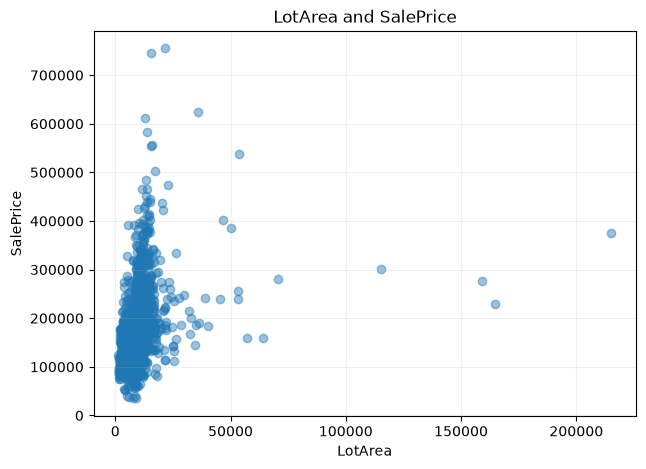

In [9]:
area_price = df[['LotArea', 'SalePrice']].dropna()
r_area, p_area = stats.pearsonr(area_price['LotArea'], area_price['SalePrice'])
r2_area = r_area ** 2
alpha = 0.05

print(f"표본 수: {len(area_price)}")
print(f"Pearson 상관계수: {r_area:.4f}")
print(f'P-value = {p_area:.4f}')
print(f"r^2 = {r2_area:.4f}")
print("유의성 판단:", "유의함" if p_area <= alpha else "유의하지 않음")

plt.figure(figsize=(7, 5))
plt.scatter(area_price['LotArea'], area_price['SalePrice'], alpha=0.45)
plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.title("LotArea and SalePrice")
plt.grid(alpha = 0.2)
plt.show()

### 분석 보고

LotArea와 SalePrice의 Pearson 상관계수는 0.2638로, 두 변수 사이에는 약한 양의 선형관계가 나타났다. p-value는 0.05보다 작기 때문에 이러한 상관관계가 통계적으로 유의한 것으로 볼 수 있다. 다만 이는 상관관계일뿐 인과관계를 의미하지 않으므로, 대지면적이 넓어지기 때문에 매매가격이 상승한다고 단정지을 수 없다. 주택의 전반적인 품질이나 지상층 생활 면적 등 다른 변수들이 매매가격에 영향을 미치는 혼란변수로 작용할 수 있기 때문이다.
또한 Pearson 상관계수가 0에 가깝더라도 비선형 관계가 존재할 수 있으므로 두 변수 사이에 아무 관계도 없다고 단정지을 수 없다. 예를 들어 U자형 관계는 값이 증가했다가 감소하는 단일 방향의 선형관계가 아니기에 Pearson 상관계수가 0에 가깝게 나타날 수 있다.

## 4장

---

### 4-1 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?
- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


기울기 beta1 = 1375.3735
절편 beta0 = -2530308.2457
회귀식: SalePrice = -2530308.25 + 1375.37 * YearBuilt

SSE : 6690269293939.84
SST : 9207911334609.98
R-squared: 0.2734
잔차: 0.0000
예측값 앞 5개: [224564.81 187429.73 221814.06 103531.95 220438.69]

YearBuilt 2000 예측가격 = 220438.69


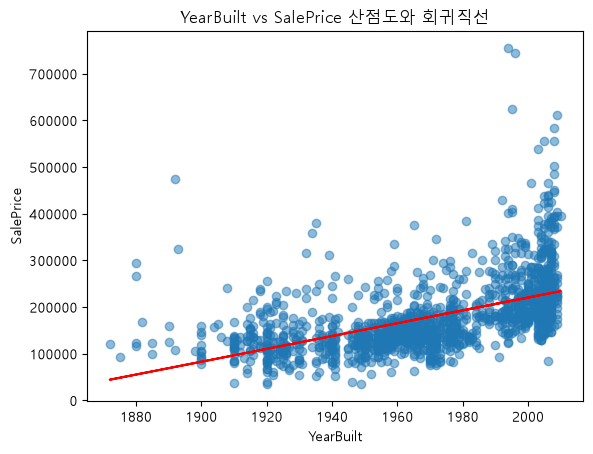

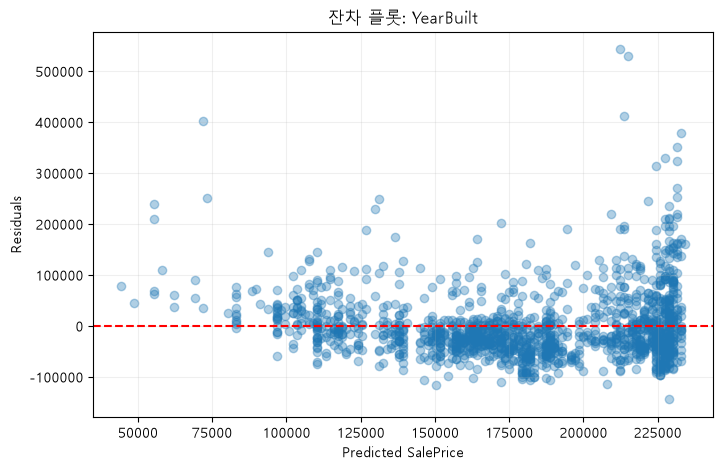

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False 


reg_data = df[['YearBuilt', 'SalePrice']].dropna()
x = reg_data['YearBuilt'].to_numpy(dtype=float)
y = reg_data['SalePrice'].to_numpy(dtype=float)

x_mean = x.mean()
y_mean = y.mean()

beta1 = np.sum((x-x_mean) * (y-y_mean)) / np.sum((x-x_mean) **2)
beta0 = y_mean - beta1 * x_mean

print(f"기울기 beta1 = {beta1:.4f}")
print(f"절편 beta0 = {beta0:.4f}")
print(f"회귀식: SalePrice = {beta0:.2f} + {beta1:.2f} * YearBuilt")

y_pred = beta0 + beta1 * x
residuals = y - y_pred

sse = np.sum(residuals ** 2)
sst = np.sum((y - y_mean) ** 2)
r_squared = 1 - (sse / sst)
residual_mean = residuals.mean()

print(f"\nSSE : {sse:.2f}")
print(f"SST : {sst:.2f}")
print(f"R-squared: {r_squared:.4f}")
print(f"잔차: {residual_mean:.4f}")
print("예측값 앞 5개:", y_pred[:5].round(2))

target_year = 2000
predicted_price_2000 = beta0 + beta1 * target_year
print(f"\nYearBuilt 2000 예측가격 = {predicted_price_2000:.2f}")

plt.scatter(x, y, alpha=0.5)
plt.plot(x, beta0 + beta1 * x, color='red', label='회귀선')
plt.xlabel('YearBuilt')
plt.ylabel('SalePrice')
plt.title('YearBuilt vs SalePrice 산점도와 회귀직선')
plt.show()  

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.title('잔차 플롯: YearBuilt')
plt.grid(alpha=0.2)
plt.show()

### 분석 보고

회귀식의 기울기 1,375.37은 건축연도가 1년 증가할 때 예측 판매가격이 평균적으로 약 1,375만큼 증가함을 의미하며, 절편 -2,530,308.25는 건축연도가 0일 때의 이론적인 예측값으로 현실적인 해석에는 한계가 있다. 결정계수는 0.2734로, 건축연도만으로 판매가격 변동의 약 27.3%를 설명하는 것으로 나타나 설명력이 높다고 보기는 어렵다. 잔차 플롯을 보면 잔차가 0을 중심으로 완전히 무작위하게 분포하지 않고, 예측 가격이 높아질수록 잔차의 분산이 커지는 경향을 보인다. 이는 오차의 분산이 일정하다는 등분산성 가정에 주의가 필요함을 보여주며, 일부 큰 잔차를 가진 관측치도 확인된다. 따라서 건축연도 하나만을 이용한 단순선형회귀로 판매가격을 충분히 설명하기에는 한계가 있다. 향후에는 주택의 전반적 품질, 면적 등 판매가격과 관련된 추가 변수를 포함한 다중회귀모형을 적용하고, 필요하다면 변수 변환이나 이상치 검토를 통해 모델을 개선할 수 있다.

## 5장

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

data_candidates = [
    Path("cookie_cats.csv"),
    Path("upload/cookie_cats.csv")]

data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("cookie_cats.csv 파일을 노트북과 같은 폴더에 넣어주세요.")

df_cats = pd.read_csv(data_path)
alpha = 0.05

---

## 5-1 과제. Cookie Cats A/B 테스트 전체 계획서 작성

`gate_30`을 기존 버전, `gate_40`을 새 버전으로 설정한 A/B 테스트 계획을 작성하세요.

### 수행 요구사항

1. 아래 네 단계를 모두 포함한 계획서를 작성하세요.
   - 가설 설정
   - 실험 설계
   - 실험 실행
   - 결과 분석
2. 실험 단위, 대조군, 실험군, 핵심·보조·가드레일 지표를 명시하세요.
3. 실행 전에 확인할 데이터 품질 항목을 두 가지 이상 작성하세요.
4. SUTVA 위반 또는 실험 간 간섭 가능성을 검토하세요.
5. 버전별 관측 지표를 다시 계산하되, 아직 통계적 검정을 하지 않았다는 점을 반영해 최종 의사결정을 보류하는 6~8문장의 결론을 작성하세요.

> 과제는 필수 문제와 동일한 수준입니다. 표본 크기나 MDE를 계산할 필요는 없습니다.

In [13]:
# 버전별 관측 지표 계산
observed_metrics = (
    df_cats.groupby("version")
      .agg(
          users=("userid", "size"),
          retention_7=("retention_7", "mean"),      
          retention_1=("retention_1", "mean"),      
          avg_gamerounds=("sum_gamerounds", "mean") 
      )
)

print("[버전별 관측 지표]")
print(observed_metrics.round(4))

[버전별 관측 지표]
         users  retention_7  retention_1  avg_gamerounds
version                                                 
gate_30  44700       0.1902       0.4482         52.4563
gate_40  45489       0.1820       0.4423         51.2988


- 본 실험은 사용자를 랜덤하게 gate_30 대조군과 gate_40 실험군에 배정하여 게이트 위치 변경이 사용자 리텐션에 미치는 영향을 확인하는 것을 목적으로 한다. 
- 핵심 지표는 장기적인 재방문을 확인하기 위한 7일 리텐션으로 설정하고, 1일 리텐션과 평균 게임 라운드 수를 보조·가드레일 지표로 함께 확인한다.
- 현재 관측된 7일 리텐션은 gate_30이 19.02%, gate_40이 18.20%로 gate_30에서 더 높게 나타났다.
- 1일 리텐션 역시 각각 44.82%, 44.23%이며, 평균 게임 라운드 수도 52.46회, 51.30회로 gate_30에서 더 높은 값이 관측되었다. 
- 그러나 이러한 차이는 표본의 무작위 변동으로도 발생할 수 있으므로, 관측값만으로 gate_30이 더 효과적이라고 결론 내릴 수 없다.
- 실험 결과를 해석하기 전에 사용자 배정 비율 및 집단 간 기본 특성의 균형을 확인하고 SRM과 SUTVA 위반 가능성도 검토해야 한다.
- 따라서 향후 7일 리텐션 차이에 대한 통계적 검정을 수행한 후 보조 및 가드레일 지표를 함께 고려하여 게이트 위치 변경 여부에 대한 최종 의사결정을 내려야 한다.

In [ ]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize
except ModuleNotFoundError:
    # statsmodels가 없는 최소 실행 환경을 위한 동일 공식의 대체 구현
    from scipy.stats import norm
    from scipy.optimize import brentq

    def proportion_effectsize(prop1, prop2):
        return 2 * np.arcsin(np.sqrt(prop1)) - 2 * np.arcsin(np.sqrt(prop2))

    class NormalIndPower:
        def solve_power(self, effect_size, nobs1=None, alpha=0.05, power=0.80,
                        ratio=1.0, alternative="two-sided"):
            if nobs1 is not None:
                raise NotImplementedError("이 노트북의 대체 구현은 표본 크기 계산만 지원합니다.")
            if alternative != "two-sided" or ratio != 1.0:
                raise NotImplementedError("양측검정과 1:1 배정만 지원합니다.")
            def achieved_power(sample1):
                sample2 = sample1 * ratio
                effective_n = 1 / (1 / sample1 + 1 / sample2)
                shift = effect_size * np.sqrt(effective_n)
                upper = norm.sf(norm.isf(alpha / 2) - shift)
                lower = norm.cdf(norm.ppf(alpha / 2) - shift)
                return upper + lower

            return brentq(lambda n: achieved_power(n) - power, 2, 1e9)

data_candidates = [Path("cookie_cats.csv"), Path("upload/cookie_cats.csv")]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("cookie_cats.csv 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05
target_power = 0.80

---

## 5-2 과제. 운영 제약을 반영한 Cookie Cats 표본 설계

다음 운영 조건에서 MDE 후보 `1.0%p`와 `1.5%p`를 비교하고 실행안을 선택하세요.

### 운영 조건

- 기준 7일 유지율: `gate_30` 관측값
- 유의수준: 0.05
- 목표 검정력: 0.80
- 양측검정, 1:1 배정
- 하루 전체 실험 대상 사용자: 5,000명
- 최대 모집 기간: 7일
- 데이터 누락·이탈 대비 여유 표본: 10%
- 비즈니스적으로 의미 있는 최소 변화: 1.5%p
- 최대 모집 기간 7일은 실험 참여자를 모집하는 기간입니다. 모든 참여자의 7일 유지율을 확인하려면 마지막 참여자 모집 후 추가로 7일의 관찰 기간이 필요합니다.

### 수행 요구사항

1. 두 MDE 후보의 기본 그룹당 표본을 계산하세요.
2. 기본 표본을 `0.90`으로 나누어 10% 누락을 고려한 그룹당 모집 목표를 계산하고 올림하세요.
3. 전체 모집 목표와 예상 모집 기간을 계산하세요.
4. 7일 안에 목표 표본 모집이 가능한지 판단하세요.
5. 아래 질문을 포함하여 5~7문장의 최종 결론을 작성하세요.

### 질문

- 어떤 MDE 설계를 선택해야 하나요?
- 선택한 설계가 통계적 조건과 비즈니스 기준을 모두 만족하나요?
- 선택하지 않은 설계는 왜 현재 운영 조건에 맞지 않나요?
- 실제 실행 전에 추가로 확인해야 할 사항은 무엇인가요?

> 과제는 필수 문제와 동일한 수준이며, 제시된 조건을 같은 계산 절차에 적용하면 됩니다.


In [14]:
import numpy as np
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# 기준 7일 유지율
p1 = df_cats.loc[df_cats["version"] == "gate_30", "retention_7"].mean()

# MDE 후보
mde_list = [0.015, 0.010]

power_analysis = NormalIndPower()

for mde in mde_list:
    p2 = p1 + mde

    effect_size = proportion_effectsize(p1, p2)

    n = power_analysis.solve_power(
        effect_size=effect_size,
        alpha=0.05,
        power=0.80,
        ratio=1.0,
        alternative="two-sided"
    )

    # 기본 그룹당 표본
    base_n = np.ceil(n)

    # 데이터 누락률 10% 반영
    recruit_n = np.ceil(base_n / 0.90)

    # 1:1 배정이므로 전체 모집 인원
    total_n = recruit_n * 2

    # 하루 최대 5,000명 모집
    recruit_days = np.ceil(total_n / 5000)

    print(f"\n[MDE {mde*100:.1f}%p]")
    print("기본 그룹당 표본:", base_n)
    print("누락 고려 그룹당 모집 목표:", recruit_n)
    print("전체 모집 목표:", total_n)
    print("예상 모집 기간:", recruit_days, "일")


[MDE 1.5%p]
기본 그룹당 표본: 11063.0
누락 고려 그룹당 모집 목표: 12293.0
전체 모집 목표: 24586.0
예상 모집 기간: 5.0 일

[MDE 1.0%p]
기본 그룹당 표본: 24658.0
누락 고려 그룹당 모집 목표: 27398.0
전체 모집 목표: 54796.0
예상 모집 기간: 11.0 일


이번 실험에는 1.5%p MDE 설계를 선택해야 한다. 1.5%p 설계는 그룹당 12,293명, 전체 24,586명 모집이 필요하며 하루 5,000명 기준으로 5일이면 모집이 완료되어, 최대 모집 기간 7일 조건을 만족한다. 반면 1.0%p 설계는 그룹당 27,398명, 전체 54,796명이 필요해 모집에만 11일이 걸리므로 7일이라는 운영 제약을 초과해 현재 조건에서는 실행할 수 없다.

따라서 1.5%p 설계는 유의수준 0.05와 검정력 0.80의 통계적 조건을 만족하면서, 비즈니스적으로 의미 있는 최소 변화인 1.5%p와 모집 기간 제약도 함께 충족한다.

1.0%p는 더 작은 변화까지 발견할 수 있어 통계적으로는 더 민감하지만, 하루 모집 가능 인원과 최대 모집 기간이라는 현실적인 제약을 벗어나므로 이번 운영 조건에는 맞지 않는다. 

실제 실행 전에는 모집 완료(5일) 후 7일 유지율을 관찰하는 데 7일이 추가적으로 필요해 실험 전체 소요시간이 12일이 된다는 점을 확인해야하며, 요일별 유입량 편차로 실제 모집속도가 하루 5,000명에 못 미칠 가능성도 함께 점검해야 한다.